In [17]:
!pip install wfdb --quiet

import os, ast, random
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter

from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import wfdb

# REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ======= PATHS (KAGGLE) ========
BASE = "/kaggle/input/ecg-detection/ptbl_xl_large_dataset"   # CHANGE IF NEEDED

DB_CSV  = os.path.join(BASE, "ptbxl_database.csv")
SCP_CSV = os.path.join(BASE, "scp_statements.csv")

print(DB_CSV)
print(SCP_CSV)


/kaggle/input/ecg-detection/ptbl_xl_large_dataset/ptbxl_database.csv
/kaggle/input/ecg-detection/ptbl_xl_large_dataset/scp_statements.csv


In [18]:
# Load metadata + scp statements
db  = pd.read_csv(DB_CSV)
scp = pd.read_csv(SCP_CSV)

# Build MI/CAD code list
mi_codes = []

for c in scp["Unnamed: 0"].astype(str):
    u = c.upper()
    if any(k in u for k in [
        "MI","IMI","AMI","INFARCTION",
        "STEMI","NSTEMI","INFERIOR MI","ANTERIOR MI","POSTERIOR MI",
        "OLD MI","OMI","PMI","LMI"
    ]):
        mi_codes.append(c)

mi_codes = set(mi_codes)

print("Total CAD/MI codes detected:", len(mi_codes))
print(list(mi_codes)[:20])


Total CAD/MI codes detected: 9
['LMI', 'PMI', 'ASMI', 'ILMI', 'IPMI', 'IPLMI', 'AMI', 'IMI', 'ALMI']


In [19]:
# Convert "scp_codes" string → Python set
def parse_scp(x):
    try:
        return set(ast.literal_eval(x).keys())
    except:
        return set()

db["scp_set"] = db["scp_codes"].apply(parse_scp)

# Create 2-class labels
def map_label_2class(s):
    if "NORM" in s:
        return 0   # NORMAL
    if len(s & mi_codes) > 0:
        return 1   # CAD / MI
    return None    # OTHER → remove later

db["label_2"] = db["scp_set"].apply(map_label_2class)

print("Distribution (including OTHER):")
print(db["label_2"].value_counts(dropna=False))


Distribution (including OTHER):
label_2
0.0    9514
NaN    6998
1.0    5287
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [20]:
db2 = db.dropna(subset=["label_2"]).copy()
db2["label_2"] = db2["label_2"].astype(int)

print("Final 2-class distribution:")
print(db2["label_2"].value_counts())


Final 2-class distribution:
label_2
0    9514
1    5287
Name: count, dtype: int64


In [21]:
cnt = db2["label_2"].value_counts()
print("Before balancing:", cnt.to_dict())

min_n = cnt.min()

idx_0 = db2[db2["label_2"] == 0].sample(min_n, random_state=SEED).index
idx_1 = db2[db2["label_2"] == 1].sample(min_n, random_state=SEED).index

db_bal = db2.loc[idx_0.union(idx_1)].sample(frac=1.0, random_state=SEED)

print("After balancing:", db_bal["label_2"].value_counts())


Before balancing: {0: 9514, 1: 5287}
After balancing: label_2
0    5287
1    5287
Name: count, dtype: int64


In [22]:
from scipy.signal import butter, filtfilt, resample

TARGET_FS = 500
TARGET_LEN = 5000
NUM_LEADS = 12

def butter_bandpass(low, high, fs, order=4):
    nyq = fs * 0.5
    return butter(order, [low/nyq, high/nyq], btype="band")

def clean_ecg(sig, fs):
    sig = np.nan_to_num(sig)

    # ensure 12 leads
    if sig.shape[1] < 12:
        sig = np.pad(sig, ((0,0),(0,12-sig.shape[1])))
    else:
        sig = sig[:, :12]

    b, a = butter_bandpass(0.5, 40, fs)

    cleaned = []
    for i in range(12):
        f = filtfilt(b,a,sig[:,i])
        cleaned.append(f)
    cleaned = np.stack(cleaned, axis=1)

    # resample
    new_len = int(cleaned.shape[0] * TARGET_FS / fs)
    cleaned = np.stack([resample(cleaned[:,i], new_len) for i in range(12)], axis=1)

    # pad/crop
    if cleaned.shape[0] > TARGET_LEN:
        start = (cleaned.shape[0] - TARGET_LEN)//2
        cleaned = cleaned[start:start+TARGET_LEN]
    else:
        pad = TARGET_LEN - cleaned.shape[0]
        cleaned = np.pad(cleaned, ((pad//2,pad-pad//2),(0,0)))

    # normalize per lead
    for i in range(12):
        std = cleaned[:,i].std()
        if std < 1e-6: return None
        cleaned[:,i] = (cleaned[:,i]-cleaned[:,i].mean()) / (std+1e-8)

    return cleaned.astype(np.float32)


In [23]:
X_list = []
y_list = []

for _, row in tqdm(db_bal.iterrows(), total=len(db_bal)):
    fpath = os.path.join(BASE, row["filename_hr"]) if isinstance(row["filename_hr"], str) else os.path.join(BASE, row["filename"])
    try:
        rec = wfdb.rdrecord(fpath)
        sig = rec.p_signal
        fs  = rec.fs
    except:
        continue
    
    clean = clean_ecg(sig, fs)
    if clean is None: continue

    X_list.append(clean)
    y_list.append(row["label_2"])

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print("Final X:", X.shape)
print("Final y:", Counter(y))


100%|██████████| 10574/10574 [02:14<00:00, 78.74it/s]


Final X: (10573, 5000, 12)
Final y: Counter({0: 5287, 1: 5286})


In [24]:
np.save("/kaggle/working/X_ptb_2class.npy", X)
np.save("/kaggle/working/y_ptb_2class.npy", y)

print("Saved:")
print("/kaggle/working/X_ptb_2class.npy")
print("/kaggle/working/y_ptb_2class.npy")


Saved:
/kaggle/working/X_ptb_2class.npy
/kaggle/working/y_ptb_2class.npy


In [25]:
import os

print(os.listdir("/kaggle/working"))


['X_ptb_2class.npy', '.virtual_documents', 'cnn_lstm_ptb_2class_best.h5', 'y_ptb_2class.npy']


In [26]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

SEED = 42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# ---- Correct folder ----
SAVE_DIR = "/kaggle/working"

# ---- Load 2-class cleaned data ----
X = np.load(os.path.join(SAVE_DIR, "X_ptb_2class.npy"))
y = np.load(os.path.join(SAVE_DIR, "y_ptb_2class.npy"))

print("Loaded X shape:", X.shape)
print("Loaded y shape:", y.shape)
print("Class counts:", Counter(y))


Loaded X shape: (10573, 5000, 12)
Loaded y shape: (10573,)
Class counts: Counter({0: 5287, 1: 5286})


In [27]:
# ==== CELL 2: train / val / test split ====

# 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=SEED
)

# remaining se 10% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.10,
    stratify=y_temp,
    random_state=SEED
)

print("Train:", X_train.shape, "Labels:", Counter(y_train))
print("Val  :", X_val.shape,   "Labels:", Counter(y_val))
print("Test :", X_test.shape,  "Labels:", Counter(y_test))


Train: (8088, 5000, 12) Labels: Counter({1: 4044, 0: 4044})
Val  : (899, 5000, 12) Labels: Counter({0: 450, 1: 449})
Test : (1586, 5000, 12) Labels: Counter({1: 793, 0: 793})


In [28]:
# ==== CELL 3: CNN + BiLSTM model ====
from tensorflow.keras import layers, models

def SE_block(x, ratio=16):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(filters // ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    return layers.Multiply()([x, se])

def res_block(x, filters, k=5):
    s = x
    x = layers.Conv1D(filters, k, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv1D(filters, k, padding="same")(x)
    x = layers.BatchNormalization()(x)

    # match dims
    if s.shape[-1] != filters:
        s = layers.Conv1D(filters, 1, padding="same")(s)

    x = layers.Add()([x, s])
    x = layers.ReLU()(x)

    return SE_block(x)

def build_best_cnn_lstm(input_shape=(5000,12)):
    inp = layers.Input(shape=input_shape)

    # Initial multi-scale CNN
    c1 = layers.Conv1D(32, 7, padding="same", activation="relu")(inp)
    c2 = layers.Conv1D(32, 5, padding="same", activation="relu")(inp)
    c3 = layers.Conv1D(32, 11, padding="same", activation="relu")(inp)

    x = layers.Concatenate()([c1, c2, c3])
    x = layers.BatchNormalization()(x)

    # Deep residual CNN blocks + pooling
    for f in [64, 128, 256]:
        x = res_block(x, f)
        x = layers.MaxPooling1D(2)(x)   # time length half each block

    # BiLSTM for temporal information
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(64))(x)

    # Dense head
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    out = layers.Dense(1, activation="sigmoid")(x)   # 2-class: NORMAL vs CAD

    model = models.Model(inp, out)
    return model

model = build_best_cnn_lstm(input_shape=(X.shape[1], X.shape[2]))
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 5000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 5000, 32)  │      2,720 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 5000, 32)  │      1,952 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 5000, 32)  │      4,256 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 5000, 96)  │          0 │ conv1d_12[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_13[0][0],  │
│                     │                   │            │ conv1d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 96)  │        384 │ concatenate_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 5000, 64)  │     30,784 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 64)  │        256 │ conv1d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 5000, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 5000, 64)  │     20,544 │ re_lu_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 64)  │        256 │ conv1d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 5000, 64)  │      6,208 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 5000, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 5000, 64)  │          0 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_7[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │        320 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 5000, 64)  │          0 │ re_lu_7[0][0],    │
│ (Multiply)          │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 2500, 64)  │          0 │ multiply_3[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 2500, 128) │     41,088 │ max_pooling1d_3[

 Total params: 1,313,405 (5.01 MB)

 Trainable params: 1,311,421 (5.00 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [29]:
# ==== CELL 4: compile + train ====

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# class weights (balanced)
classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}
print("Class weights:", class_weight_dict)

# compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# checkpoint path
ckpt_path = "/kaggle/working/cnn_lstm_ptb_2class_best.h5"

# callbacks
cbs = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True, verbose=1)
]

# train model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=cbs,
    verbose=1
)

print("Best weights saved at:", ckpt_path)


Class weights: {0: 1.0, 1: 1.0}
Epoch 1/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.7404 - loss: 0.5230
Epoch 1: val_loss improved from inf to 0.37300, saving model to /kaggle/working/cnn_lstm_ptb_2class_best.h5


253/253 ━━━━━━━━━━━━━━━━━━━━ 83s 287ms/step - accuracy: 0.7406 - loss: 0.5226 - val_accuracy: 0.8276 - val_loss: 0.3730 - learning_rate: 1.0000e-04
Epoch 2/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.8713 - loss: 0.3184
Epoch 2: val_loss improved from 0.37300 to 0.27072, saving model to /kaggle/working/cnn_lstm_ptb_2class_best.h5


253/253 ━━━━━━━━━━━━━━━━━━━━ 71s 280ms/step - accuracy: 0.8714 - loss: 0.3183 - val_accuracy: 0.8865 - val_loss: 0.2707 - learning_rate: 1.0000e-04
Epoch 3/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8883 - loss: 0.2688
Epoch 3: val_loss improved from 0.27072 to 0.24923, saving model to /kaggle/working/cnn_lstm_ptb_2class_best.h5


253/253 ━━━━━━━━━━━━━━━━━━━━ 71s 279ms/step - accuracy: 0.8884 - loss: 0.2688 - val_accuracy: 0.8966 - val_loss: 0.2492 - learning_rate: 1.0000e-04
Epoch 4/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.8991 - loss: 0.2489
Epoch 4: val_loss improved from 0.24923 to 0.24646, saving model to /kaggle/working/cnn_lstm_ptb_2class_best.h5


253/253 ━━━━━━━━━━━━━━━━━━━━ 71s 280ms/step - accuracy: 0.8991 - loss: 0.2488 - val_accuracy: 0.8999 - val_loss: 0.2465 - learning_rate: 1.0000e-04
Epoch 5/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9053 - loss: 0.2322
Epoch 5: val_loss improved from 0.24646 to 0.24267, saving model to /kaggle/working/cnn_lstm_ptb_2class_best.h5


253/253 ━━━━━━━━━━━━━━━━━━━━ 71s 279ms/step - accuracy: 0.9053 - loss: 0.2321 - val_accuracy: 0.9032 - val_loss: 0.2427 - learning_rate: 1.0000e-04
Epoch 6/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9181 - loss: 0.2089
Epoch 6: val_loss improved from 0.24267 to 0.23951, saving model to /kaggle/working/cnn_lstm_ptb_2class_best.h5


253/253 ━━━━━━━━━━━━━━━━━━━━ 71s 279ms/step - accuracy: 0.9181 - loss: 0.2089 - val_accuracy: 0.9032 - val_loss: 0.2395 - learning_rate: 1.0000e-04
Epoch 7/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.9253 - loss: 0.1961
Epoch 7: val_loss did not improve from 0.23951
253/253 ━━━━━━━━━━━━━━━━━━━━ 70s 278ms/step - accuracy: 0.9253 - loss: 0.1960 - val_accuracy: 0.8988 - val_loss: 0.2519 - learning_rate: 1.0000e-04
Epoch 8/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9366 - loss: 0.1713
Epoch 8: val_loss did not improve from 0.23951
253/253 ━━━━━━━━━━━━━━━━━━━━ 70s 278ms/step - accuracy: 0.9366 - loss: 0.1713 - val_accuracy: 0.9010 - val_loss: 0.2560 - learning_rate: 1.0000e-04
Epoch 9/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9455 - loss: 0.1527
Epoch 9: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 9: val_loss did not improve from 0.23951
253/253 ━━━━━━━━━━━━━━━━━━━━ 70s 278ms/step - accuracy: 0.9455 - loss: 0.1

In [31]:
# ==== CELL: Load best model + Evaluate on TEST ====
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# checkpoint path from training cell
ckpt_path = "/kaggle/working/cnn_lstm_ptb_2class_best.h5"

model.load_weights(ckpt_path)
print("Loaded best model:", ckpt_path)

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print("\n========= TEST PERFORMANCE =========")
print(f"Accuracy: {test_acc:.4f}")
print(f"Loss    : {test_loss:.4f}")

# Predictions
y_prob = model.predict(X_test, batch_size=64)
y_pred = (y_prob[:,0] >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Loaded best model: /kaggle/working/cnn_lstm_ptb_2class_best.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.8843 - loss: 0.2740

========= TEST PERFORMANCE =========
Accuracy: 0.8897
Loss    : 0.2649
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step

Classification Report:
              precision    recall  f1-score   support

           0     0.8824    0.8991    0.8907       793
           1     0.8972    0.8802    0.8886       793

    accuracy                         0.8897      1586
   macro avg     0.8898    0.8897    0.8896      1586
weighted avg     0.8898    0.8897    0.8896      1586


Confusion Matrix:
[[713  80]
 [ 95 698]]


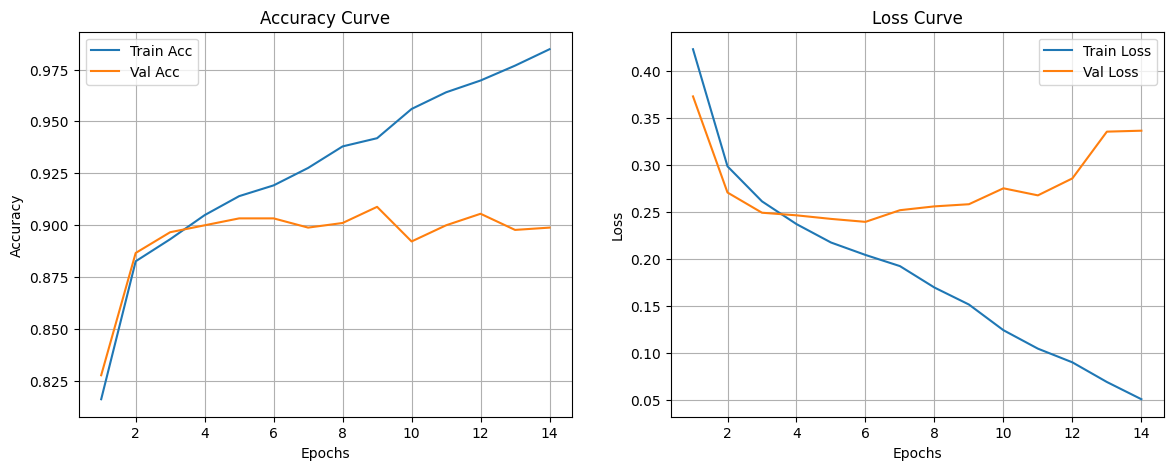

In [32]:
# ==== CELL: Accuracy & Loss Graphs ====
import matplotlib.pyplot as plt

acc      = history.history["accuracy"]
val_acc  = history.history["val_accuracy"]
loss     = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc)+1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, label="Train Acc")
plt.plot(epochs, val_acc, label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.show()


In [33]:
# ==== CELL: Signal formatting ====
from scipy.signal import resample

def format_sig_5000x12(sig):
    sig = np.array(sig, dtype="float32")

    if sig.ndim == 1:
        sig = sig[:, None]

    if sig.shape[0] < sig.shape[1] and sig.shape[0] <= 12:
        sig = sig.T

    if sig.shape[1] < 12:
        sig = np.pad(sig, ((0,0),(0,12-sig.shape[1])), 'constant')
    elif sig.shape[1] > 12:
        sig = sig[:, :12]

    L = sig.shape[0]
    if L != 5000:
        out = np.zeros((5000, 12), dtype="float32")
        for i in range(12):
            out[:, i] = resample(sig[:, i], 5000)
    else:
        out = sig

    # normalize
    for i in range(12):
        m, s = out[:,i].mean(), out[:,i].std()
        if s < 1e-6: out[:,i] = 0
        else:        out[:,i] = (out[:,i] - m) / (s+1e-8)

    return out


In [34]:
import wfdb
import pandas as pd
import os

def load_npy(path):
    return format_sig_5000x12(np.load(path))

def load_csv(path):
    df = pd.read_csv(path)
    return format_sig_5000x12(df.to_numpy())

def load_dat(path):
    if path.endswith(".dat"):
        path = path[:-4]

    rec = wfdb.rdrecord(path)
    return format_sig_5000x12(rec.p_signal)


In [35]:
CLASS = {0: "NORMAL", 1: "CAD"}

def predict_ecg(path):
    ext = os.path.splitext(path)[1].lower()

    if ext == ".dat":
        sig = load_dat(path)
    elif ext == ".npy":
        sig = load_npy(path)
    elif ext == ".csv":
        sig = load_csv(path)
    else:
        raise ValueError("Unsupported file type")

    sig = np.expand_dims(sig, axis=0)

    prob = float(model.predict(sig)[0][0])
    pred = int(prob >= 0.5)

    print("\n========= PREDICTION =========")
    print("File  :", path)
    print("Class :", CLASS[pred])
    print(f"Prob(CAD): {prob:.4f}")
    print(f"Prob(NORMAL): {1-prob:.4f}")

    return pred, prob


In [42]:
predict_ecg("/kaggle/input/ecg-detection/ptbl_xl_large_dataset/records500/00000/00146_hr.dat")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

========= PREDICTION =========
File  : /kaggle/input/ecg-detection/ptbl_xl_large_dataset/records500/00000/00146_hr.dat
Class : CAD
Prob(CAD): 0.9939
Prob(NORMAL): 0.0061


(1, 0.9938534498214722)